# GNN for Graph Level Predictions about Knots (Volume)

Juan José H. Beltrán

In [16]:
# Requirements:
# !pip install numpy pandas scikit-learn torch torch_geometric matplotlib

In [17]:
import dataset
from torch_geometric.loader import DataLoader
from settings import *

## Create Dataset and Dataloader

In [18]:
train_loader, val_loader, deg, knot_dataset = dataset.load()

# Esto debería pasarse a dataset.py
testGeneralisazion = DataLoader(dataset.fetchDataset("datasets/linkDataset.csv")["dataPoint"], batch_size = BATCH_SIZE)

Dataset consists of  2381 train samples and  596 test samples
max_degree: 11


### Explore Dataset

Cada dataset contiene una fila por cada grafo. Cada grafo tiene a su vez:
- `x`: Tensor con las features de los nodos. En este caso contiene el grado del nodo (input features: 1).
- `edge_index`: Tensor con la descripción de las aristas del grafo, especificando su origen y destino.
- `edge_atrr`: Tensor con los atributos de cada arista del grafo. En este caso son la "distancia" y si está o no "alternando".
- `y`: Tensor con los labels. En este caso, es un único label para todo el grafo: el invariante a predecir.

In [19]:
knot_dataset = knot_dataset.dataPoint

In [20]:
knot_dataset[0].edge_index

tensor([[0, 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5],
        [5, 2, 1, 4, 0, 0, 4, 3, 5, 2, 1, 2, 5, 0, 3, 4]])

## Functions and Classes for GNN

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from settings import *

In [22]:
# Import custom GNN models from models.py
from models import PNAKnotNet
from models import GATKnotNet
from models import TransKnotNet

In [23]:
torch.manual_seed(31)
model = PNAKnotNet(deg)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 20, min_lr = 0.00001)

In [24]:
def train(epoch):
    model.train()

    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        if LOSS == "abs":
            loss = (out.squeeze() - data.y).abs().mean() # Mean Absolute Error
        elif LOSS == "squared":
            loss = (out.squeeze() - data.y).square().mean() # Mean Squared Error

        loss.backward()
        total_loss += loss.item() * data.num_graphs
        optimizer.step()

    return total_loss / len(train_loader.dataset)

In [25]:
@torch.no_grad()
def test(loader):
    model.eval()

    total_error = 0
    for data in loader:
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        if LOSS=="abs":
            total_error += (out.squeeze() - data.y).abs().sum().item()
        elif LOSS=="squared":
            total_error += (out.squeeze() - data.y).square().sum().item()
    
    return total_error / len(loader.dataset)

## Train Model

In [26]:
try_generalization = True

history_train_loss = []
history_val_loss = []
history_gen_loss = []
history_gen_acc = []

for epoch in range(1, 250):
    val_loss = test(val_loader)
    if try_generalization:
        gen_loss = test(testGeneralisazion)
    loss = train(epoch)

    # Append history for plotting later
    history_train_loss.append(loss)
    history_val_loss.append(val_loss)
    if try_generalization:
        history_gen_loss.append(gen_loss)

    scheduler.step(loss)
    if try_generalization:
        print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}, Generalization loss: {gen_loss:.4f}')
    else:
        print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}')

Epoch: 01, Train loss: 229.4573, Val loss: 242.5339, Generalization loss: 33.2703
Epoch: 02, Train loss: 211.8434, Val loss: 228.2051, Generalization loss: 27.8528
Epoch: 03, Train loss: 183.4855, Val loss: 204.0267, Generalization loss: 18.6946
Epoch: 04, Train loss: 147.2305, Val loss: 171.6043, Generalization loss: 9.5327
Epoch: 05, Train loss: 108.9515, Val loss: 133.0957, Generalization loss: 2.3104
Epoch: 06, Train loss: 76.0947, Val loss: 96.9619, Generalization loss: 16.2776
Epoch: 07, Train loss: 49.3056, Val loss: 65.0764, Generalization loss: 27.5095
Epoch: 08, Train loss: 32.7483, Val loss: 43.0174, Generalization loss: 21.1880
Epoch: 09, Train loss: 27.7745, Val loss: 56.5665, Generalization loss: 26.8443
Epoch: 10, Train loss: 16.4490, Val loss: 22.0589, Generalization loss: 105.6321
Epoch: 11, Train loss: 13.4556, Val loss: 15.6856, Generalization loss: 119.0902
Epoch: 12, Train loss: 11.6802, Val loss: 13.1317, Generalization loss: 119.9152
Epoch: 13, Train loss: 10.570

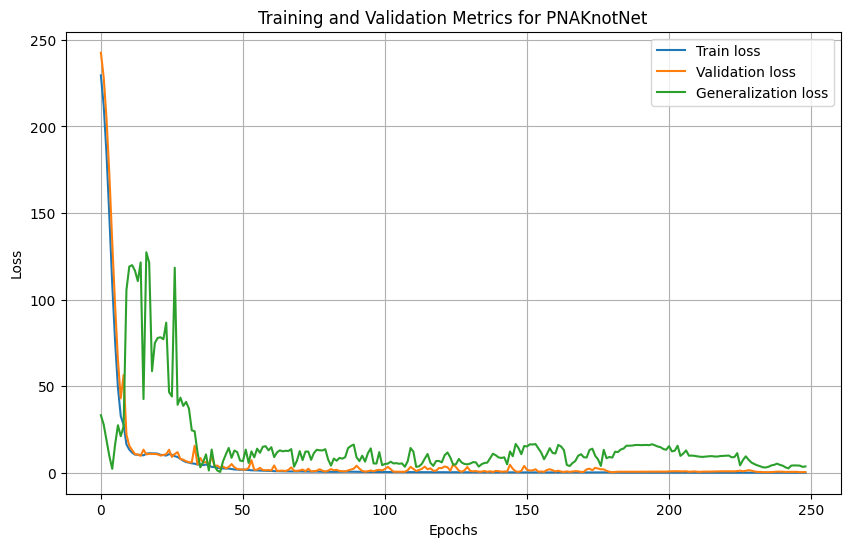

In [27]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
if try_generalization:
    plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Training and Validation Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

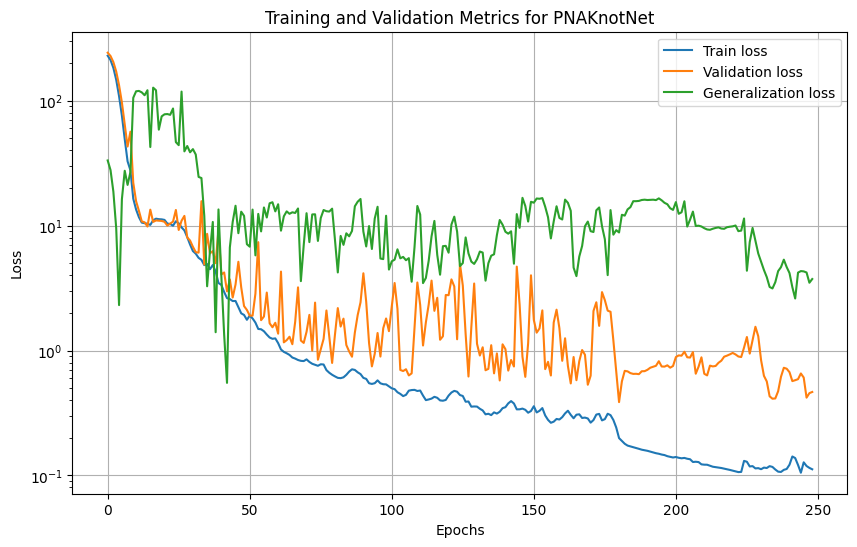

In [28]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
if try_generalization:
    plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Training and Validation Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [29]:
# Save the trained model
# torch.save(model.state_dict(), f"models/{model._get_name()}_{FEATURE}_{LOSS}_bs{BATCH_SIZE}_add{ADDITIONAL}.pt")